# Self Ordering Map

As neural networks go, SOMs are relatively simple. As such, we can impliment them without needing fancy libraries or expensive hardware. Our implimentation will not necessarily be the fastest or most efficient, but it should give you a good idea of how a SOM works. Of course, the libaries and hardware can make things go quicker, and you can optimise the code yourself if you want to.

Let's include our libraries.

In [1]:
import numpy as np              #To make some operations easier
import matplotlib.pyplot as plt #To see what we are doing

To see how a SOM works, we will start with some 2D input data first, before pushing it to higher dimensions.

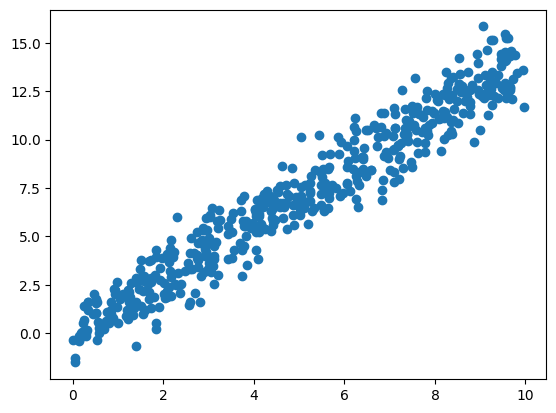

In [2]:
#While we play around, we want our results to be repeatable. So let's set a seed
np.random.seed(256)

#Lets draw data scattered around y=1.4x
x = np.random.uniform(size=500)*10
y = np.random.normal(loc=(1.4*x))
toy = np.vstack((x,y)).T

plt.scatter(toy[:,0], toy[:,1])
plt.show()

We now need a grid of cells. Here, we will reduce our "high" dimensional space into 2D. Each cell should be mapped to a random position (unit) in the origional dataspace. We also need to know which cells are neighbours in the low dimensional space. As we are going to use this to reduce in higher dimensions, make your code generalisable to deal with any number of higher dimensions.

(3, 3, 2)


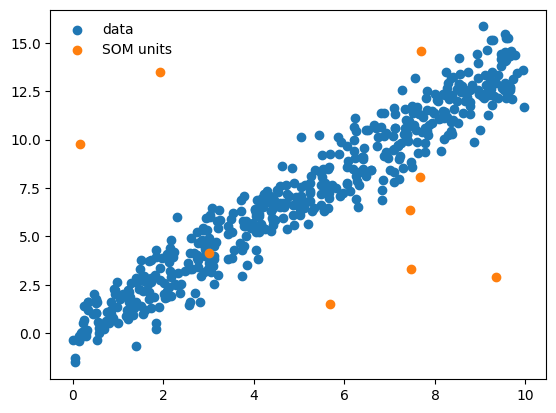

In [3]:
def init_cells(X, n=9):
    
    #####################
    d = X.shape[1]
    
    n_x = np.sqrt(n).astype(int)
    n_y = np.sqrt(n).astype(int)
    dy = n - (n_x*n_y)
    n_y += dy

    minmax = []
    for i in range(0, d):
        minmax.append([np.min(X[:,i]), np.max(X[:,i])])
    minmax = np.array(minmax)

    cells = []
    for i in range(0, n_x):
        cells_y = []
        for j in range(0, n_y):
            weights = []
            for k in range(0, d):
                weights.append(np.random.uniform(minmax[k,0], minmax[k,1]))
            cells_y.append(weights)
        cells.append(cells_y)

    cells = np.array(cells)
    #####################
    
    return cells

cells = init_cells(toy)
print(cells.shape)

plt.scatter(toy[:,0], toy[:,1], label='data')
plt.scatter(cells[:,:,0], cells[:,:,1], label='SOM units')
plt.legend(loc=0, frameon=False)
plt.show()

To get the SOM to work, we need a couple of things:

<ul>
    <li>The Best Matching Unit (BMU)</li>
    <li>A way to update the position (weights) of the units</li>
    <li>The strength of the "pull" to other, non-BMU, units (h)</li>
    <li>The learning rate (α)</li>
    <li>The learning schedule</li>
</ul>

Let's start by finding the BMU for a specific point x<sub>i</sub>.

In [4]:
def get_BMU(x_i, cells):
    
    #####################
    BMU = np.unravel_index(np.argmin(np.linalg.norm(cells - x_i, axis=2)), cells.shape[:2])
    #####################
    
    return BMU

BMU = get_BMU(toy[0], cells)
print(BMU)

(np.int64(0), np.int64(1))


Lets now define the "decay" (h) we want to apply to the other units when BMU moved, based on the separation to the BMU _in lower dimensional space_ (s). You can set this to be however you want, but an easy way is h = 1/2<sup>s</sup>.

In [5]:
def h_(s):

    #####################
    if s < 64:
        h = 1/np.power(2, s)
    else:
        h = 0
    #####################
    
    return h

h = h_(0)
print(h)

1.0


Now we can update the weights of unit j in high dimensional space when comparing to the data point x<sub>i</sub>. This should be the origional weight of unit j (w<sub>j</sub>) plus the difference between w<sub>j</sub> and x<sub>i</sub> including a scaling with h and α.

In [6]:
def update_weight(w_j, x_i, alpha, s):

    #####################
    w_j_new = w_j + (alpha * h_(s) * (x_i-w_j))
    #####################
    
    return w_j_new

w_j = update_weight(cells[BMU], toy[0], 0.1, 0)
print(w_j)

[2.74646452 3.84523865]


Of course, we need to update the weights of all units when comparing to x<sub>i</sub>, so write a wrapper to do that, assuming we know BMU.

In [7]:
def update_all_weights(cells, x_i, alpha, BMU):

    #####################
    cells_new = cells.copy()
    for i in range(0, len(cells)):
        for j in range(0, len(cells[i])):
            s = abs(BMU[0] - i) + abs(BMU[1] - j)
            cells_new[i,j] = update_weight(cells[i,j], x_i, alpha, s)
    cells = cells_new
    #####################
    
    return cells

cells = update_all_weights(cells, toy[0], 0.1, BMU)

Finall, the learning schedule. This will update α at the end of each iteraton (or batch if you prefer) This can change α however you want.

In [8]:
def update_alpha(alpha):

    #####################
    alpha *= 0.95
    #####################
    
    return alpha

We have all the components of our SOM. Now we need to put them together and run it over some number of iterations. For now, let's keep it quick and only do a few iterations.

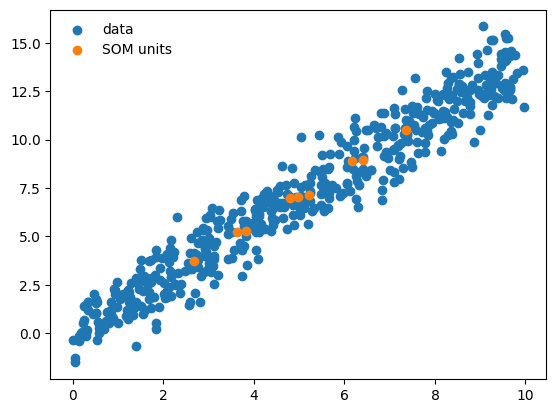

In [9]:
def SOM(X, n_cells=9, alpha=0.1, iterations=10, batches=None):

    #####################
    np.random.seed(256)
    batches = 10
    
    cells = init_cells(X, n=n_cells)

    for _ in range(0, iterations):
        idx = np.arange(0, len(X))
        np.random.shuffle(idx)

        if batches is not None:
            batches_idx = np.array_split(idx, batches)
        else:
            batches_idx = [idx]

        for batch in batches_idx:
            x_batch = X[batch]
            for x_i in x_batch:
                BMU = get_BMU(x_i, cells) # np.unravel_index(np.argmin(np.linalg.norm(cells - x_i, axis=2)), cells.shape[:2])
                cells = update_all_weights(cells, x_i, alpha, BMU)
                
            alpha = update_alpha(alpha)
    #####################

    return cells

cells = SOM(toy, n_cells=9, alpha=0.1, iterations=10)

plt.scatter(toy[:,0], toy[:,1], label='data')
plt.scatter(cells[:,:,0], cells[:,:,1], label='SOM units')
plt.legend(loc=0, frameon=False)
plt.show()

Hopefully, your SOM units are now inside your data (or at least starting to look like they are moving that way). Play around with the learning rate, the decay on aplha, the number of iterations, h_, and the other hyper parameters until it is looking more like how you want it to. We are about to push it to higher dimensions.

## Higher dimensions

Let's get some 6D data so we can at leasy try to see what's going on.

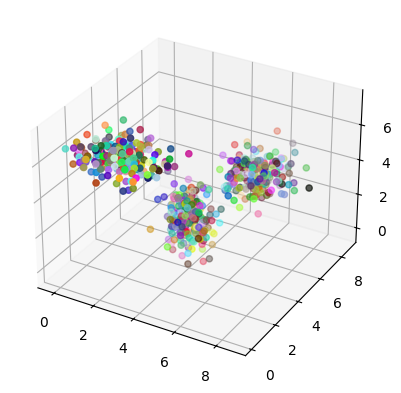

In [10]:
#While we play around, we want our results to be repeatable. So let's set a seed
np.random.seed(256)

#Draw 200 random points from a 3D Gaussian with
point_1 = np.random.multivariate_normal([2,2,6], [[0.75,0.00,0.00],[0.00,0.50,0.00],[0.00,0.00,0.25]], 200) #mean=[2,2,6] and std=[0.75,0.50,0.25]
point_2 = np.random.multivariate_normal([6,6,4], [[0.50,0.00,0.00],[0.00,0.75,0.00],[0.00,0.00,0.25]], 200) #mean=[6,6,4] and std=[0.50,0.75,0.25]
point_3 = np.random.multivariate_normal([4,4,2], [[0.25,0.00,0.00],[0.00,0.25,0.00],[0.00,0.00,0.75]], 200) #mean=[4,4,2] and std=[0.25,0.25,0.75]
points = np.vstack((point_1, point_2, point_3))
#Draw 3 values between 0 and 1 for each point (this are effectivly RGB colours, to help visualise 6D)
colour = np.random.uniform(low=[0,0,0], high=[1,1,1], size=[len(points),3]) #
X = np.hstack((points, colour))

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], color=X[:,3:])
plt.show()

Let's run the SOM on this new data. Hopefully you made it able to deal with higher dimensions.

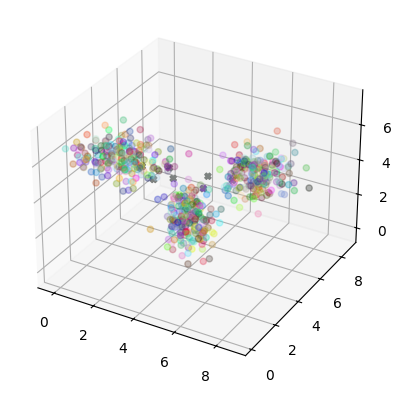

In [11]:
cells = SOM(X, n_cells=9, alpha=0.1, iterations=10)

cells_x = []
cells_y = []
cells_z = []
cells_c = []
for i in range(0, len(cells)):
    for j in range(0, len(cells[i])):
        cells_x.append(cells[i,j,0])
        cells_y.append(cells[i,j,1])
        cells_z.append(cells[i,j,2])
        cells_c.append(cells[i,j,3:])

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], color=X[:,3:], alpha=0.3)
ax.scatter(cells_x, cells_y, cells_z, color=cells_c, marker='X', alpha=1.0)
plt.show()

We can see the location of the units in the higher dimensions. But what about in 2D.

Each point of our data will map to the BMU and be placed in the 2D position of the BMU. So will need to record the x-y posion in the 2D space that each high dimensional point maps to.

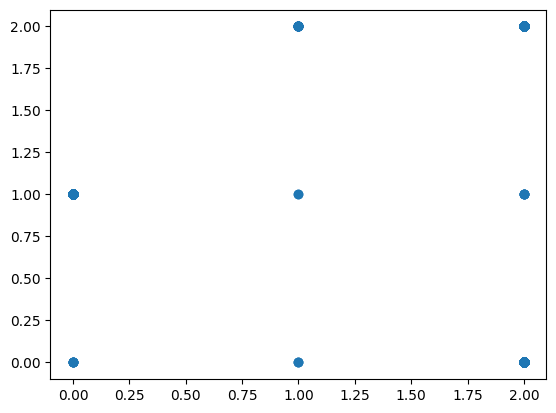

In [12]:
def SOM_down_project(cells, X):

    #####################
    low_d_mapping = []
    for x_i in X:
        BMU = get_BMU(x_i, cells)
        low_d_mapping.append(list(BMU))
    low_d_mapping = np.array(low_d_mapping)
    #####################

    return low_d_mapping

ldm_X = SOM_down_project(cells, X)
plt.scatter(ldm_X[:,0], ldm_X[:,1])
plt.show()

Nine cells is probably not enough to accurately map our data. So let's use more cells and see what we get. Depending on your h_(s) function and the number of cells, you may also have issues with large distances if you did not catch it already.

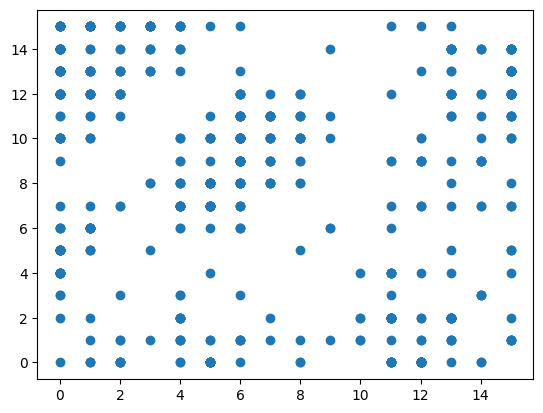

In [13]:
cells = SOM(X, n_cells=256, alpha=0.1, iterations=10)
Z = SOM_down_project(cells, X)
plt.scatter(Z[:,0], Z[:,1])
plt.show()

We can also put new data into our SOM prjection

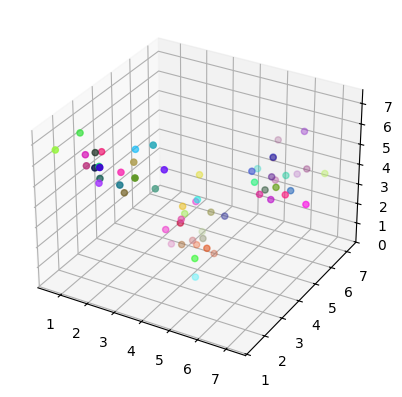

In [14]:
#Draw 20 random points from a 3D Gaussian with
point_1 = np.random.multivariate_normal([2,2,6], [[0.75,0.00,0.00],[0.00,0.50,0.00],[0.00,0.00,0.25]], 20) #mean=[2,2,6] and std=[0.75,0.50,0.25]
point_2 = np.random.multivariate_normal([6,6,4], [[0.50,0.00,0.00],[0.00,0.75,0.00],[0.00,0.00,0.25]], 20) #mean=[6,6,4] and std=[0.50,0.75,0.25]
point_3 = np.random.multivariate_normal([4,4,2], [[0.25,0.00,0.00],[0.00,0.25,0.00],[0.00,0.00,0.75]], 20) #mean=[4,4,2] and std=[0.25,0.25,0.75]
points = np.vstack((point_1, point_2, point_3))
#Draw 3 values between 0 and 1 for each point (this are effectivly RGB colours, to help visualise 6D)
colour = np.random.uniform(low=[0,0,0], high=[1,1,1], size=[len(points),3]) #
Y = np.hstack((points, colour))

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color=Y[:,3:])
plt.show()

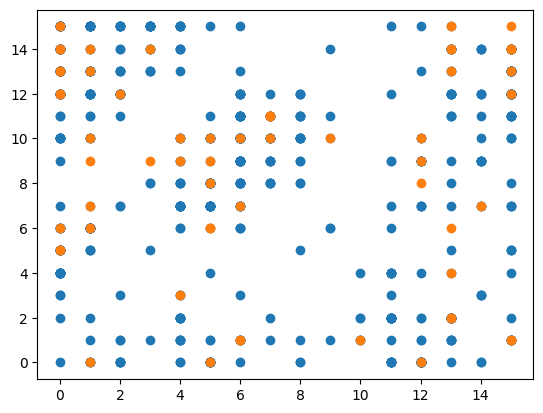

In [15]:
Z_Y = SOM_down_project(cells, Y)
plt.scatter(Z[:,0], Z[:,1], label='Original')
plt.scatter(Z_Y[:,0], Z_Y[:,1], label='New')
plt.show()

Let's save our Z data for this afternoon.

In [16]:
np.save('SOM_Z.npy', Z)

## Real Data

Now let's play with some real data! MorphologicalCat_VISTULA.csv contains morphologies for 10943 galaxies observed by KiDS. Let's grab that data!

In [17]:
#The first row is the header, so we will skip that
data = np.genfromtxt('MorphologicalCat_VISTULA.csv', dtype=float, delimiter=',')[1:]

Now run your SOM on the data.

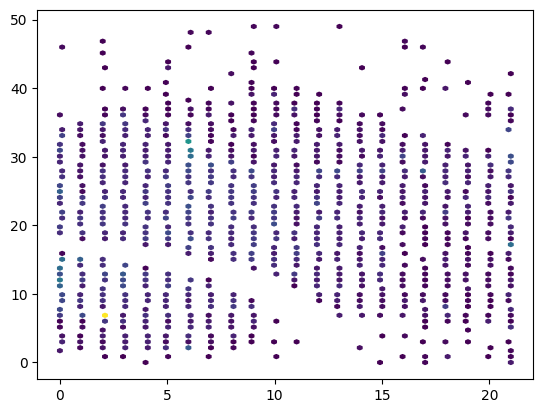

In [18]:
cells = SOM(data, n_cells=512, alpha=0.1, iterations=10)
Z_data = SOM_down_project(cells, data)
plt.hexbin(Z_data[:,0], Z_data[:,1], mincnt=1)
plt.show()

That looks sort of like two clusters. Remember, the SOM axes don't really tell us anything in and of themselves. So we don't know what these clusters are from the x and y axes. We would need to find the members of the clusters and eximin them closer. Let's save this 2D reduction for now.

In [19]:
np.save('SOM_data.npy', Z_data)